<h1 style='text-align:center;
           color:#7B1113;
           font-size:42px;
           font-family:Arial;'>
NLP CLASSIFICATION & SENTIMENT ANALYSIS
</h1>

<h3 style='text-align:center;
           color:#444;
           font-family:Arial;'>
Restaurant Reviews • Text Classification • Sentiment Detection
</h3>

<div style="display:flex;
            justify-content:center;
            margin-top:30px;">

<img src='https://assets.simpleviewcms.com/simpleview/image/fetch/c_pad,h_600,q_75,w_1122/https://lasvegas.simpleviewcrm.com/images/listings/original_Bacchanal-Buffet-at-Caesars-Palace.jpg'
     width='700'
     style='border-radius:20px;
            box-shadow:0px 6px 20px rgba(0,0,0,0.35);'></div><br>

<p style='text-align:center;
          font-size:18px;
          color:#555;
          font-family:Arial;'>

This project focuses on Natural Language Processing (NLP),
text classification, and sentiment analysis using restaurant reviews.</p>

<h2 style='color:#7B1113;
           font-family:Arial;
           font-size:24px;'>
Project Workflow
</h2>

<ol style='font-size:14px;
           line-height:1.7;
           font-family:Arial;
           color:#333;'>

<li>
<b>Import Libraries</b> – 
Required libraries for NLP, visualization, machine learning, SMOTE, readability analysis, and pipelines are imported.
</li>

<li>
<b>Load Dataset</b> – 
The restaurant review dataset is loaded into Python using Pandas.
</li>

<li>
<b>Dataset Exploration</b> – 
The dataset structure, column names, missing values, and class distributions are analyzed.
</li>

<li>
<b>Sentiment Label Creation</b> – 
Review scores are converted into sentiment labels:
Positive (1) and Negative (0).
Neutral reviews are removed from the dataset.
</li>

<li>
<b>Text Cleaning with NeatText</b> – 
Text preprocessing operations such as stopword removal, punctuation removal, and special character cleaning are performed using the NeatText library.
</li>

<li>
<b>Readability Analysis</b> – 
The readability level of customer reviews is analyzed using readability metrics.
</li>

<li>
<b>Feature Extraction with TF-IDF</b> – 
Text data is transformed into numerical vectors using TF-IDF vectorization.
</li>

<li>
<b>Train-Test Split</b> – 
The dataset is divided into training and testing sets for model evaluation.
</li>

<li>
<b>Handling Imbalanced Data with SMOTE</b> – 
SMOTE is applied to balance positive and negative sentiment classes in the training data.
</li>

<li>
<b>Machine Learning Pipeline</b> – 
A machine learning pipeline is created by combining TF-IDF vectorization and Logistic Regression classification.
</li>

<li>
<b>Model Training & Prediction</b> – 
The model is trained using the training dataset and predictions are generated on the test dataset.
</li>

<li>
<b>Model Evaluation</b> – 
The model performance is evaluated using accuracy score, classification report, and confusion matrix.
</li>

<li>
<b>Results & Conclusion</b> – 
The final findings are interpreted and the effectiveness of the NLP sentiment analysis model is discussed.
</li></ol>



In [26]:
#pip install neattext

Note: you may need to restart the kernel to use updated packages.


In [27]:
#pip install textstat

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------- -------------- 1.3/2.1 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 9.4 MB/s  0:00:00

   -------------------- ------------------- 1/2 [textstat]
   -------------------- ------------------- 1/2 [textstat]
   -------------------- ------------------- 1/2 [textstat]
   ---------------------------------------- 2/2 [textstat]

Note: you may need to restart the kernel to use updated packages.


In [28]:
#pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [29]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import neattext.functions as nfx

# Readability
import textstat

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Pipeline
from sklearn.pipeline import Pipeline

# SMOTE
from imblearn.over_sampling import SMOTE

In [14]:
df = pd.read_csv("restaurant.csv")
df.head()

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,2370338,_WTGv5XnA-qb_XD1D7Z0jg,6PgdGb3HrZdsfl2GiULo8w,RESDUcs7fIiihp38-d6_6g,5,0,1,0,After getting food poisoning at the Palms hote...,2012-12-04 03:10:18
1,2370357,JlNnsvMPLK_1-X2hwzK24w,IS9yw8P2uAPBX6FNLLX4KA,RESDUcs7fIiihp38-d6_6g,4,39,21,29,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",2014-01-17 00:50:50
2,2370373,hBkoWffORRb6aqKhC_Li2A,uZdFsE_aHbFBChgN6Xa8tw,RESDUcs7fIiihp38-d6_6g,4,1,1,1,The crab legs are better than the ones at Wick...,2015-06-08 18:03:09
3,2370411,rbkxvrgZg5kdCL2a66QYmA,8ZWJNAEWsymXDzKx3B0tTQ,RESDUcs7fIiihp38-d6_6g,1,0,0,0,Not worth it! Too salty food and expensive! Th...,2016-12-19 16:15:29
4,2370500,5tw_pedoHVi9bgeiBNsISg,E0sm4Ve7ifanFYeQMcV8Eg,RESDUcs7fIiihp38-d6_6g,5,0,0,0,I would give this infinite stars if I could. M...,2015-07-28 07:13:17


In [31]:
# Dataset Shape
print("Dataset Shape:", df.shape)
# Column Names
print(df.columns)
# Dataset Info
df.info()

Dataset Shape: (8856, 3)
Index(['text', 'stars', 'sentiment'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 8856 entries, 0 to 10416
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       8856 non-null   object
 1   stars      8856 non-null   int64 
 2   sentiment  8856 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 276.8+ KB


In [32]:
df.isnull().sum()

text         0
stars        0
sentiment    0
dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10417 entries, 0 to 10416
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   10417 non-null  int64 
 1   review_id    10417 non-null  object
 2   user_id      10417 non-null  object
 3   business_id  10417 non-null  object
 4   stars        10417 non-null  int64 
 5   useful       10417 non-null  int64 
 6   funny        10417 non-null  int64 
 7   cool         10417 non-null  int64 
 8   text         10417 non-null  object
 9   date         10417 non-null  object
dtypes: int64(5), object(5)
memory usage: 814.0+ KB


In [17]:
# Missing values
df.isnull().sum()

Unnamed: 0     0
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

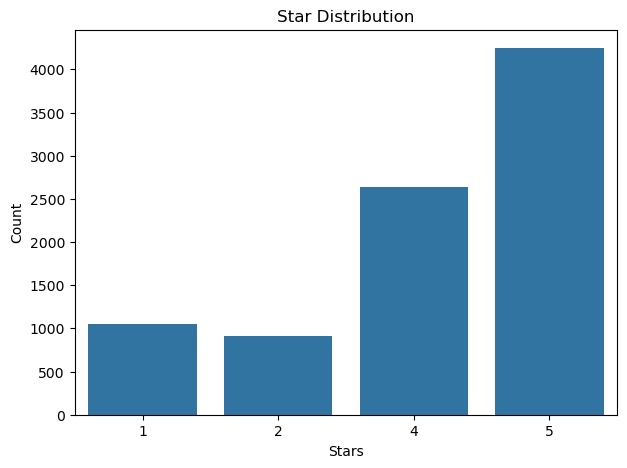

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(x=df["stars"])

plt.title("Star Distribution")

plt.xlabel("Stars")

plt.ylabel("Count")

plt.show()

In [70]:
# Star percentage distribution

(df["stars"].value_counts(normalize=True) * 100).round(2)

stars
5    47.96
4    29.77
1    11.92
2    10.35
Name: proportion, dtype: float64

### Observation:
#### The dataset contains more positive reviews than negative reviews.
#### 5-star reviews are dominant, indicating customer satisfaction is generally high.
#### This imbalance may affect model performance during classification.

In [55]:
df = df[["text", "stars"]]

df.head()

,text,stars
0,After getting food poisoning at the Palms hote...,5
1,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",4
2,The crab legs are better than the ones at Wick...,4
3,Not worth it! Too salty food and expensive! Th...,1
4,I would give this infinite stars if I could. M...,5


In [71]:
# SENTIMENT LABEL ENCODING

# 1-2 stars = Negative sentiment = 0
# 4-5 stars = Positive sentiment = 1
# 3 stars = Neutral reviews, removed from the dataset

df = df[df["stars"] != 3]

df["sentiment"] = df["stars"].apply(lambda x: 1 if x > 3 else 0)

df.head()

,text,stars,sentiment
0,After getting food poisoning at the Palms hote...,5,1
1,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",4,1
2,The crab legs are better than the ones at Wick...,4,1
3,Not worth it! Too salty food and expensive! Th...,1,0
4,I would give this infinite stars if I could. M...,5,1


In [72]:
# Check sentiment labels

print("0 = Negative Review")
print("1 = Positive Review")

df["sentiment"].value_counts()

0 = Negative Review
1 = Positive Review


sentiment
1    6883
0    1973
Name: count, dtype: int64

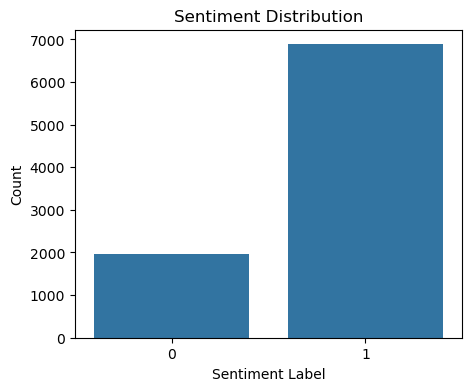

In [73]:
# SENTIMENT DISTRIBUTION ANALYSIS

plt.figure(figsize=(5,4))
sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

In [59]:
# Sentiment percentage distribution

(df["sentiment"].value_counts(normalize=True) * 100).round(2)

sentiment
1    77.72
0    22.28
Name: proportion, dtype: float64

### Observation:
#### The dataset is imbalanced because positive reviews represent 77.72% 
#### of the data, while negative reviews represent only 22.28%.
#### This imbalance may bias the machine learning model toward the majority class.
#### Therefore, SMOTE will be applied later to balance the dataset.

# TEXT CLEANING WITH NEATTEXT

In [75]:

# Remove stopwords
df["clean_text"] = df["text"].apply(nfx.remove_stopwords)

# Remove special characters
df["clean_text"] = df["clean_text"].apply(
    nfx.remove_special_characters)

# Remove punctuations
df["clean_text"] = df["clean_text"].apply(
    nfx.remove_punctuations)

df[["text", "clean_text"]].head()

,text,clean_text
0,After getting food poisoning at the Palms hote...,getting food poisoning Palms hotel scared eat ...
1,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",A feast worthy Gods Baccarnal Buffet Caesar Pa...
2,The crab legs are better than the ones at Wick...,crab legs better ones Wicked Spoon huge prawns...
3,Not worth it! Too salty food and expensive! Th...,worth it salty food expensive furst kast visit...
4,I would give this infinite stars if I could. M...,infinite stars could family diamond card Caesa...


In [76]:
print("Original Review:\n")
print(df["text"].iloc[0])

print("\n----------------------------\n")

print("Cleaned Review:\n")
print(df["clean_text"].iloc[0])

Original Review:

After getting food poisoning at the Palms hotel, I was scared to eat at any more buffets. But we figured with the high price tag, the positive reviews etc, it was worth a chance. I'm really glad we gave it a try. (btw I uploaded a collage of the things we ate)

The seafood line is by the far the longest, i would not recommend showing up in heels if you're female, my feet were killing me between the line at the door, the line to get sat, and the seafood line. Totally worth it though.

The prime rib was the best Ive ever had.

I loved the sweet potato tots.

I even have PHO!

The music was great and so was our server Alma, ( he was a older gentleman with a mustache and was very attentive and delightful).

I will return next trip in more comfortable shoes. After a horrible visit at the palms with non stop issues in a matter of 48 hours, your establishment was truly the high light of our trip. Thank you for an exquisite dinner.

----------------------------

Cleaned Revie

# READABILITY ANALYSIS

In [62]:
df["readability_score"] = df["text"].apply(
    lambda x: textstat.flesch_reading_ease(str(x)))
df[["text", "readability_score"]].head()

,text,readability_score
0,After getting food poisoning at the Palms hote...,76.544201
1,"""A feast worthy of Gods""\n\nBaccarnal Buffet i...",77.033647
2,The crab legs are better than the ones at Wick...,83.040935
3,Not worth it! Too salty food and expensive! Th...,87.945000
4,I would give this infinite stars if I could. M...,79.528571


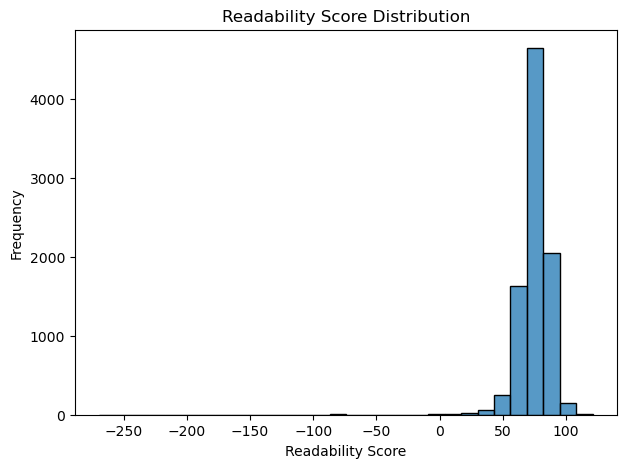

In [63]:
# Readability score distribution

plt.figure(figsize=(7,5))
sns.histplot(df["readability_score"], bins=30)
plt.title("Readability Score Distribution")
plt.xlabel("Readability Score")
plt.ylabel("Frequency")
plt.show()

### Observation:
#### Most readability scores are concentrated between 50 and 90.
#### This indicates that customer reviews are generally easy to read
#### and written in simple everyday language.
#### A few extreme values may result from short or irregular reviews.

In [64]:
print("Average Readability Score:")

print(df["readability_score"].mean())

Average Readability Score:
75.437820010522


In [77]:
#FEATURE SELECTION FOR MODEL

X = df["clean_text"]
y = df["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8856,)
y shape: (8856,)


# TF-IDF VECTORIZATION

In [78]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (8856, 5000)


In [79]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (7084, 5000)
X_test shape: (1772, 5000)


In [22]:
df["sentiment"].value_counts()

sentiment
1    6883
0    1973
Name: count, dtype: int64

# APPLY SMOTE

In [81]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
sentiment
1    5506
0    1578
Name: count, dtype: int64

After SMOTE:
sentiment
1    5506
0    5506
Name: count, dtype: int64


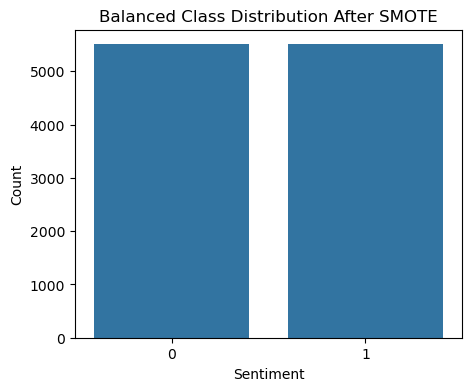

In [82]:
plt.figure(figsize=(5,4))

sns.countplot(x=y_train_smote)

plt.title("Balanced Class Distribution After SMOTE")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [84]:
# MODEL TRAINING

model = LogisticRegression(max_iter=1000)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

In [85]:
#  MODEL EVALUATION

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9051918735891648

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.90      0.81       395
           1       0.97      0.91      0.94      1377

    accuracy                           0.91      1772
   macro avg       0.85      0.90      0.87      1772
weighted avg       0.92      0.91      0.91      1772



In [87]:
from sklearn.metrics import confusion_matrix

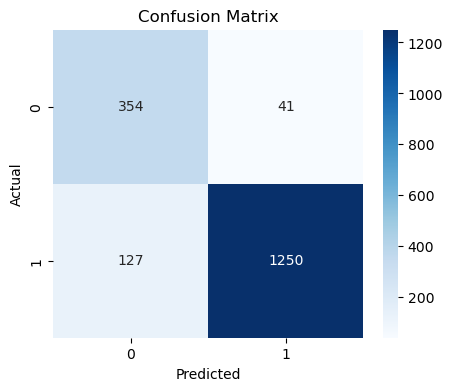

In [88]:
#  CONFUSION MATRIX

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [89]:
print(accuracy_score(y_test, y_pred))

0.9051918735891648


# PIPELINE WITH TF-IDF + SMOTE + LOGISTIC REGRESSION

In [90]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))])

In [91]:
# TRAIN TEST SPLIT FOR PIPELINE

X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

In [92]:
# TRAIN PIPELINE MODEL

pipeline.fit(X_train, y_train)

y_pred_pipeline = pipeline.predict(X_test)

In [93]:
# PIPELINE MODEL EVALUATION

print("Pipeline Accuracy Score:", accuracy_score(y_test, y_pred_pipeline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pipeline))

Pipeline Accuracy Score: 0.912528216704289

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       395
           1       0.97      0.92      0.94      1377

    accuracy                           0.91      1772
   macro avg       0.86      0.91      0.88      1772
weighted avg       0.92      0.91      0.92      1772



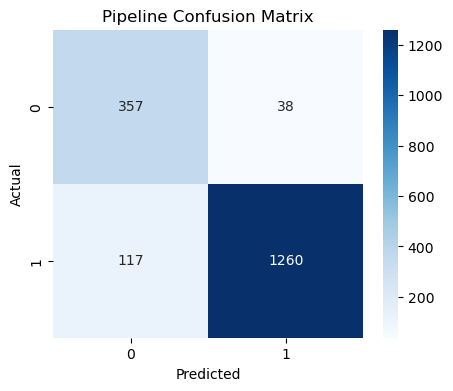

In [94]:
# PIPELINE CONFUSION MATRIX

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_pipeline),
    annot=True,
    fmt="d",
    cmap="Blues")

plt.title("Pipeline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [95]:
# PIPELINE ACCURACY SCORE

pipeline_accuracy = accuracy_score(y_test, y_pred_pipeline)

print("Pipeline Accuracy Score:", pipeline_accuracy)
print("Pipeline Accuracy Percentage:", round(pipeline_accuracy * 100, 2), "%")

Pipeline Accuracy Score: 0.912528216704289
Pipeline Accuracy Percentage: 91.25 %


In [98]:
# TEST WITH NEW REVIEWS

new_reviews = ["The food was amazing and the service was excellent.",
    "The meal was cold, expensive, and the service was terrible."]

predictions = pipeline.predict(new_reviews)

for review, prediction in zip(new_reviews, predictions):
    print("Review:", review)
    
    if prediction == 1:
        print("Predicted Sentiment: Positive")
    else:
        print("Predicted Sentiment: Negative")
        
    print("-" * 50)

Review: The food was amazing and the service was excellent.
Predicted Sentiment: Positive
--------------------------------------------------
Review: The meal was cold, expensive, and the service was terrible.
Predicted Sentiment: Negative
--------------------------------------------------


<h2 style='color:#7B1113;
           font-family:Arial;
           font-size:28px;
           text-align:center;'>
Project Conclusion
</h2>

<div style='font-family:Arial;
            font-size:15px;
            line-height:1.7;
            color:#333;
            border:1px solid #ddd;
            border-radius:12px;
            padding:20px;
            background-color:#fafafa;'>

<p>
In this project, restaurant reviews were analyzed using Natural Language Processing techniques.
The main objective was to classify customer reviews as positive or negative based on their textual content.
</p>

<p>
First, star ratings were converted into binary sentiment labels. Reviews with 1–2 stars were labeled as
<b>negative (0)</b>, while reviews with 4–5 stars were labeled as <b>positive (1)</b>.
Neutral reviews with 3 stars were removed from the dataset.
</p>

<p>
Text preprocessing was performed using the <b>NeatText</b> library. Stopwords, punctuation marks,
and special characters were removed from review texts. Additionally, <b>readability analysis</b>
was conducted to examine how easy or difficult the reviews were to read.
</p>

<p>
Since the sentiment classes were imbalanced, <b>SMOTE</b> was applied to balance the training data.
Then, a machine learning pipeline was built using <b>TF-IDF Vectorization</b>,
<b>SMOTE</b>, and <b>Logistic Regression</b>.
</p>

<p>
The final pipeline model achieved approximately <b>91% accuracy</b>.
This result shows that the model successfully classified restaurant reviews into positive
and negative sentiment categories.
</p>

<p>
Overall, the combination of NeatText, readability analysis, SMOTE, TF-IDF, and Logistic Regression
provided an effective and systematic approach for NLP-based sentiment classification.
</p></div>
